In [4]:
from google.colab import files
uploaded = files.upload()

Saving train.txt.txt to train.txt.txt


In [5]:
import os
os.listdir()

['.config', 'train.txt.txt', 'sample_data']

In [6]:
import pandas as pd

data = pd.read_csv("train.txt.txt", sep=";", names=["text","emotion"])
data.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [7]:
data.shape

(16000, 2)

In [8]:
data['emotion'].value_counts()

,count
emotion,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


In [9]:
data.head(10)

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


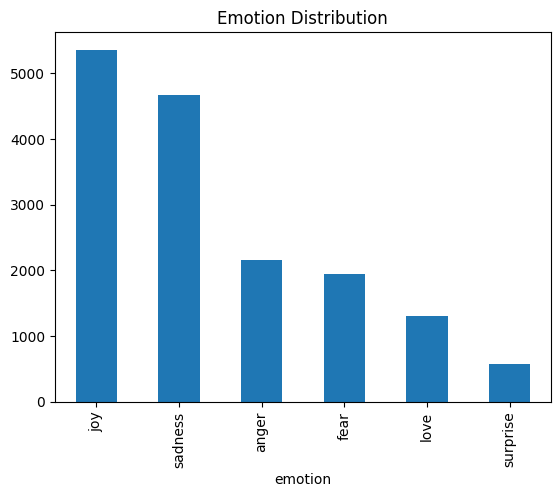

In [10]:
import matplotlib.pyplot as plt

data['emotion'].value_counts().plot(kind='bar')
plt.title("Emotion Distribution")
plt.show()

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(data['text'])
y = data['emotion']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [34]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6165625


In [35]:
text = ["I am very happy today"]

vector = vectorizer.transform(text)

prediction = model.predict(vector)

print("Emotion:", prediction[0])

Emotion: joy


In [36]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

data['clean_text'] = data['text'].apply(clean_text)

In [37]:
import random
import time
import sys

def typing_effect(text):
    for char in text:
        sys.stdout.write(char)
        sys.stdout.flush()
        time.sleep(0.03)
    print()

while True:
    user_input = input("You: ")

    if user_input.lower() == "stop":
        typing_effect("Okay, take care 😊")
        break

    vector = vectorizer.transform([user_input])
    prediction = model.predict(vector)

    emotion = prediction[0]


    if emotion == "joy":
        responses = [
            "That’s really nice to hear 😊",
            "You seem happy!",
            "That sounds great!",
            "Love that!"
        ]

    elif emotion == "sadness":
        responses = [
            "That sounds tough…",
            "I'm here for you.",
            "Do you want to talk about it?",
            "Hope things get better soon."
        ]

    elif emotion == "anger":
        responses = [
            "That sounds frustrating.",
            "I understand why you're upset.",
            "Try to take a deep breath.",
            "Want to talk it out?"
        ]

    else:
        responses = [
            "I understand.",
            "Tell me more.",
            "I'm listening.",
            "Go on..."
        ]

    reply = random.choice(responses)

    typing_effect(reply)

You: i am feeling sad
Hope things get better soon.
You: i am very angry
Try to take a deep breath.
You: can you help
That sounds great!
You: stop
Okay, take care 😊


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       anger       0.91      0.17      0.28       427
        fear       0.93      0.11      0.19       397
         joy       0.54      0.99      0.70      1021
        love       1.00      0.01      0.01       296
     sadness       0.69      0.89      0.78       946
    surprise       0.00      0.00      0.00       113

    accuracy                           0.62      3200
   macro avg       0.68      0.36      0.33      3200
weighted avg       0.71      0.62      0.52      3200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


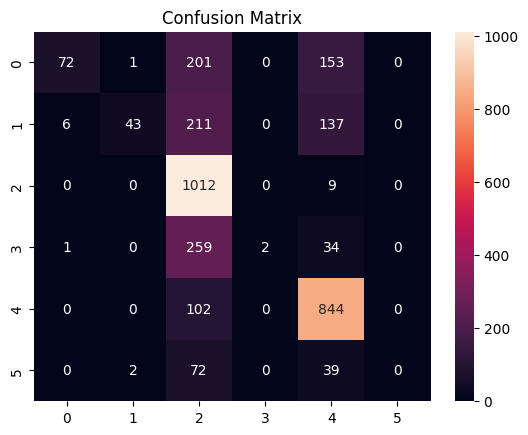

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [38]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

In [43]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X = vectorizer.fit_transform(data['clean_text'])   # 🔥 THIS LINE IS MISSING
y = data['emotion']

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [45]:
import re
import random

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

while True:
    user_input = input("You: ")

    if user_input.lower() == "stop":
        print("Okay, take care 😊")
        break

    clean = clean_text(user_input)

    vector = vectorizer.transform([clean])
    prediction = model.predict(vector)

    print("Emotion:", prediction[0])

You: i am very sad
Emotion: sadness
You: i am feelin happy
Emotion: joy
You: stop
Okay, take care 😊


In [47]:
print("Emotion:", prediction[0])

Emotion: joy


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       anger       0.15      0.03      0.05       435
        fear       0.17      0.02      0.04       385
         joy       0.33      0.59      0.43      1057
        love       0.00      0.00      0.00       254
     sadness       0.31      0.40      0.35       951
    surprise       0.00      0.00      0.00       118

    accuracy                           0.32      3200
   macro avg       0.16      0.17      0.14      3200
weighted avg       0.24      0.32      0.26      3200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
